# Phase 5: Comprehensive Evaluation & Ablation Study
Loads all models from Phases 1-4 and evaluates against multiple attack types.

### Evaluation suite:
- Clean accuracy, FGSM, PGD-20, PGD-100
- Ablation: effect of tau, number of experts, compression ratio
- Speed & compression metrics

In [1]:
import os, time
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchattacks
import numpy as np
from torch.utils.data import DataLoader

from utils import (
    device, evaluate, load_checkpoint, count_zero_params, count_conv_sparsity
)
from ensemble_utils import SME_Ensemble, MVC_NNT

print(f'Device: {device}')

Device: cuda


In [2]:
transform_test = transforms.Compose([transforms.ToTensor()])
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

eps, alpha = 8/255, 2/255
print(f'Test set: {len(testset)} images')

Test set: 10000 images


In [3]:
# ==========================================================================
# LOAD ALL MODELS FROM ALL PHASES
# ==========================================================================
models = {}

# Phase 1: Base model
base = torchvision.models.resnet18(weights=None, num_classes=10).to(device)
base = load_checkpoint(base, 'checkpoints/resnet18_standard_best.pth')
models['Base'] = base

# Phase 1: Magnitude pruning baseline
if os.path.exists('checkpoints/mag_final_best.pth'):
    mag = torchvision.models.resnet18(weights=None, num_classes=10).to(device)
    mag = load_checkpoint(mag, 'checkpoints/mag_final_best.pth')
    models['Magnitude-50'] = mag

# Phase 2: ExPSO experts
for r in [30, 50, 70]:
    path = f'checkpoints/expso_expert_{r}.pth'
    if os.path.exists(path):
        m = torchvision.models.resnet18(weights=None, num_classes=10).to(device)
        m = load_checkpoint(m, path)
        models[f'ExPSO-{r}'] = m

# Phase 3: SME Ensemble
if os.path.exists('checkpoints/sme_ensemble_final_v2.pth'):
    experts_sme = []
    for r in [30, 50, 70]:
        m = torchvision.models.resnet18(weights=None, num_classes=10).to(device)
        m = load_checkpoint(m, f'checkpoints/expso_expert_{r}.pth')
        experts_sme.append(m)
    sme = SME_Ensemble(experts_sme, num_classes=10).to(device)
    sme.load_state_dict(torch.load('checkpoints/sme_ensemble_final_v2.pth'))
    models['SME'] = sme

# Phase 4: MVC-NNT
mvc_exists = all(os.path.exists(f'checkpoints/mvc_expert_{r}_v2.pth') for r in [30, 50, 70])
if mvc_exists:
    experts_mvc = []
    for r in [30, 50, 70]:
        m = torchvision.models.resnet18(weights=None, num_classes=10).to(device)
        m = load_checkpoint(m, f'checkpoints/mvc_expert_{r}_v2.pth')
        experts_mvc.append(m)
    mvc = MVC_NNT(experts_mvc).to(device)
    models['MVC-NNT'] = mvc

print(f'Loaded {len(models)} models: {list(models.keys())}')
# Phase 5: Ultimate Defense (SME + MVC)
if os.path.exists('checkpoints/sme_mvc_ultimate_v2.pth'):
    experts_ult = []
    for r in [30, 50, 70]:
        m = torchvision.models.resnet18(weights=None, num_classes=10).to(device)
        m = load_checkpoint(m, f'checkpoints/mvc_expert_{r}_v2.pth')
        experts_ult.append(m)
    ult = SME_Ensemble(experts_ult, num_classes=10).to(device)
    ult.load_state_dict(torch.load('checkpoints/sme_mvc_ultimate_v2.pth'))
    models['Ultimate-Defense'] = ult



Loaded 7 models: ['Base', 'Magnitude-50', 'ExPSO-30', 'ExPSO-50', 'ExPSO-70', 'SME', 'MVC-NNT']


In [4]:
# ==========================================================================
# COMPREHENSIVE EVALUATION
# ==========================================================================
results = []

for name, model in models.items():
    print(f'\nEvaluating {name}...')
    model.eval()

    # Clean accuracy
    clean = evaluate(model, testloader)

    # FGSM
    fgsm = evaluate(model, testloader, atk=torchattacks.FGSM(model, eps=eps))

    # PGD-20
    pgd20 = evaluate(model, testloader,
        atk=torchattacks.PGD(model, eps=eps, alpha=alpha, steps=20))

    # PGD-100
    pgd100 = evaluate(model, testloader,
        atk=torchattacks.PGD(model, eps=eps, alpha=alpha, steps=100))

    # Sparsity
    if hasattr(model, 'models'):  # MVC_NNT
        sparsity = np.mean([count_zero_params(m) for m in model.models])
    elif hasattr(model, 'experts'):  # SME_Ensemble
        sparsity = np.mean([count_zero_params(e) for e in model.experts])
    else:
        sparsity = count_zero_params(model)

    results.append({
        'Method': name, 'Clean': clean,
        'FGSM': fgsm, 'PGD-20': pgd20, 'PGD-100': pgd100,
        'Sparsity': sparsity
    })
    print(f'  Clean={clean:.2f}% | FGSM={fgsm:.2f}% | PGD-20={pgd20:.2f}% | PGD-100={pgd100:.2f}% | Sparsity={sparsity:.1f}%')


Evaluating Base...
  Clean=88.78% | FGSM=22.51% | PGD-20=0.40% | PGD-100=0.10% | Sparsity=0.0%

Evaluating Magnitude-50...
  Clean=68.74% | FGSM=43.72% | PGD-20=38.89% | PGD-100=38.79% | Sparsity=49.2%

Evaluating ExPSO-30...
  Clean=71.46% | FGSM=45.05% | PGD-20=39.28% | PGD-100=39.04% | Sparsity=30.3%

Evaluating ExPSO-50...
  Clean=69.05% | FGSM=44.14% | PGD-20=39.00% | PGD-100=38.77% | Sparsity=53.7%

Evaluating ExPSO-70...
  Clean=65.99% | FGSM=41.72% | PGD-20=37.41% | PGD-100=37.21% | Sparsity=73.7%

Evaluating SME...
  Clean=71.36% | FGSM=51.33% | PGD-20=47.75% | PGD-100=47.46% | Sparsity=52.5%

Evaluating MVC-NNT...
  Clean=68.45% | FGSM=47.36% | PGD-20=43.66% | PGD-100=43.43% | Sparsity=52.5%

Evaluating Ultimate-Defense...
  Clean=71.36% | FGSM=50.74% | PGD-20=47.26% | PGD-100=46.99% | Sparsity=52.5%


In [5]:
# ==========================================================================
# RESULTS TABLE
# ==========================================================================
print('\n' + '='*75)
print('COMPREHENSIVE RESULTS: All Phases')
print('='*75)
print(f'{"Method":<14} {"Clean":>8} {"FGSM":>8} {"PGD-20":>8} {"PGD-100":>8} {"Sparse":>8}')
print('-'*75)
for r in results:
    print(f'{r["Method"]:<14} {r["Clean"]:>7.2f}% {r["FGSM"]:>7.2f}% {r["PGD-20"]:>7.2f}% {r["PGD-100"]:>7.2f}% {r["Sparsity"]:>7.1f}%')


COMPREHENSIVE RESULTS: All Phases
Method            Clean     FGSM   PGD-20  PGD-100   Sparse
---------------------------------------------------------------------------
Base             88.78%   22.51%    0.40%    0.10%     0.0%
Magnitude-50     68.74%   43.72%   38.89%   38.79%    49.2%
ExPSO-30         71.46%   45.05%   39.28%   39.04%    30.3%
ExPSO-50         69.05%   44.14%   39.00%   38.77%    53.7%
ExPSO-70         65.99%   41.72%   37.41%   37.21%    73.7%
SME              71.36%   51.33%   47.75%   47.46%    52.5%
MVC-NNT          68.45%   47.36%   43.66%   43.43%    52.5%
Ultimate-Defense   71.36%   50.74%   47.26%   46.99%    52.5%


In [6]:
# ==========================================================================
# INFERENCE SPEED BENCHMARKS
# ==========================================================================
print('\n' + '='*60)
print('INFERENCE SPEED BENCHMARKS')
print('='*60)

# Warm up GPU
dummy = torch.randn(1, 3, 32, 32).to(device)
for _ in range(10):
    _ = base(dummy)

n_runs = 100
batch = torch.randn(100, 3, 32, 32).to(device)

for name, model in models.items():
    model.eval()
    torch.cuda.synchronize() if device.type == 'cuda' else None
    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(batch)
    torch.cuda.synchronize() if device.type == 'cuda' else None
    elapsed = time.time() - start
    throughput = (n_runs * 100) / elapsed
    latency = elapsed / (n_runs * 100) * 1000
    print(f'{name:<14} | Throughput: {throughput:>8.0f} img/s | Latency: {latency:>6.3f} ms/img')

# Model sizes
print('\nModel Sizes (checkpoint files):')
for ckpt in ['resnet18_standard_best.pth', 'mag_final_best.pth',
             'expso_expert_30.pth', 'expso_expert_50.pth', 'expso_expert_70.pth',
             'sme_ensemble_final_v2.pth', 'mvc_expert_30.pth', 'sme_mvc_ultimate_v2.pth']:
    path = f'checkpoints/{ckpt}'
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f'  {ckpt}: {size_mb:.1f} MB')


INFERENCE SPEED BENCHMARKS
Base           | Throughput:    21125 img/s | Latency:  0.047 ms/img
Magnitude-50   | Throughput:    18375 img/s | Latency:  0.054 ms/img
ExPSO-30       | Throughput:    18305 img/s | Latency:  0.055 ms/img
ExPSO-50       | Throughput:    18471 img/s | Latency:  0.054 ms/img
ExPSO-70       | Throughput:    18641 img/s | Latency:  0.054 ms/img
SME            | Throughput:     6078 img/s | Latency:  0.165 ms/img
MVC-NNT        | Throughput:    19372 img/s | Latency:  0.052 ms/img
Ultimate-Defense | Throughput:     6536 img/s | Latency:  0.153 ms/img

Model Sizes (checkpoint files):
  resnet18_standard_best.pth: 42.7 MB
  mag_final_best.pth: 84.6 MB
  expso_expert_30.pth: 84.6 MB
  expso_expert_50.pth: 84.6 MB
  expso_expert_70.pth: 84.6 MB
  sme_ensemble_final_v2.pth: 131.3 MB
  mvc_expert_30.pth: 84.6 MB
  sme_mvc_ultimate_v2.pth: 131.3 MB


In [7]:
# ==========================================================================
# AUTOATTACK EVALUATION (Gold Standard for Robustness)
# Includes: APGD-CE, APGD-DLR, FAB, Square Attack
# Uses version='rand' for stochastic/randomized defense models (SME, MVC)
# ==========================================================================
try:
    from autoattack import AutoAttack
    print('AutoAttack loaded.')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'autoattack'])
    from autoattack import AutoAttack
    print('AutoAttack installed and loaded.')

# Collect full test set for AutoAttack (it expects all images at once)
all_images, all_labels = [], []
for imgs, lbls in testloader:
    all_images.append(imgs)
    all_labels.append(lbls)
all_images = torch.cat(all_images).to(device)
all_labels = torch.cat(all_labels).to(device)

# Use a subset (1000 images) for speed — AutoAttack is very slow on full 10k
n_aa = 1000
aa_images = all_images[:n_aa]
aa_labels = all_labels[:n_aa]

print(f'\nAutoAttack evaluation on {n_aa} images (eps={eps:.4f})')
print('='*60)

# Models with stochastic inference need version='rand' (uses EoT)
stochastic_models = {'SME', 'MVC-NNT', 'Ultimate-Defense'}

aa_results = {}
for name, model in models.items():
    print(f'\n--- {name} ---')
    model.eval()
    try:
        aa_version = 'rand' if name in stochastic_models else 'standard'
        adversary = AutoAttack(model, norm='Linf', eps=eps, version=aa_version, verbose=False)
        x_adv = adversary.run_standard_evaluation(aa_images, aa_labels, bs=128)
        # Compute accuracy on adversarial examples
        with torch.no_grad():
            outputs = model(x_adv)
            _, predicted = outputs.max(1)
            correct = predicted.eq(aa_labels).sum().item()
            aa_acc = 100. * correct / n_aa
        aa_results[name] = aa_acc
        print(f'{name}: AutoAttack Robust Accuracy = {aa_acc:.2f}%')
    except Exception as e:
        print(f'{name}: AutoAttack failed — {e}')
        aa_results[name] = 'Error'

print(f'\n{"Method":<14} {"AutoAttack":>12}')
print('-'*30)
for name, acc in aa_results.items():
    if isinstance(acc, float):
        print(f'{name:<14} {acc:>11.2f}%')
    else:
        print(f'{name:<14} {acc:>12}')



AutoAttack loaded.

AutoAttack evaluation on 1000 images (eps=0.0314)

--- Base ---
Base: AutoAttack Robust Accuracy = 0.00%

--- Magnitude-50 ---
Magnitude-50: AutoAttack Robust Accuracy = 35.80%

--- ExPSO-30 ---
ExPSO-30: AutoAttack Robust Accuracy = 34.90%

--- ExPSO-50 ---
ExPSO-50: AutoAttack Robust Accuracy = 35.00%

--- ExPSO-70 ---
ExPSO-70: AutoAttack Robust Accuracy = 33.50%

--- SME ---
SME: AutoAttack Robust Accuracy = 38.40%

--- MVC-NNT ---
MVC-NNT: AutoAttack Robust Accuracy = 45.20%

--- Ultimate-Defense ---
Ultimate-Defense: AutoAttack Robust Accuracy = 38.60%

Method           AutoAttack
------------------------------
Base                  0.00%
Magnitude-50         35.80%
ExPSO-30             34.90%
ExPSO-50             35.00%
ExPSO-70             33.50%
SME                  38.40%
MVC-NNT              45.20%
Ultimate-Defense       38.60%


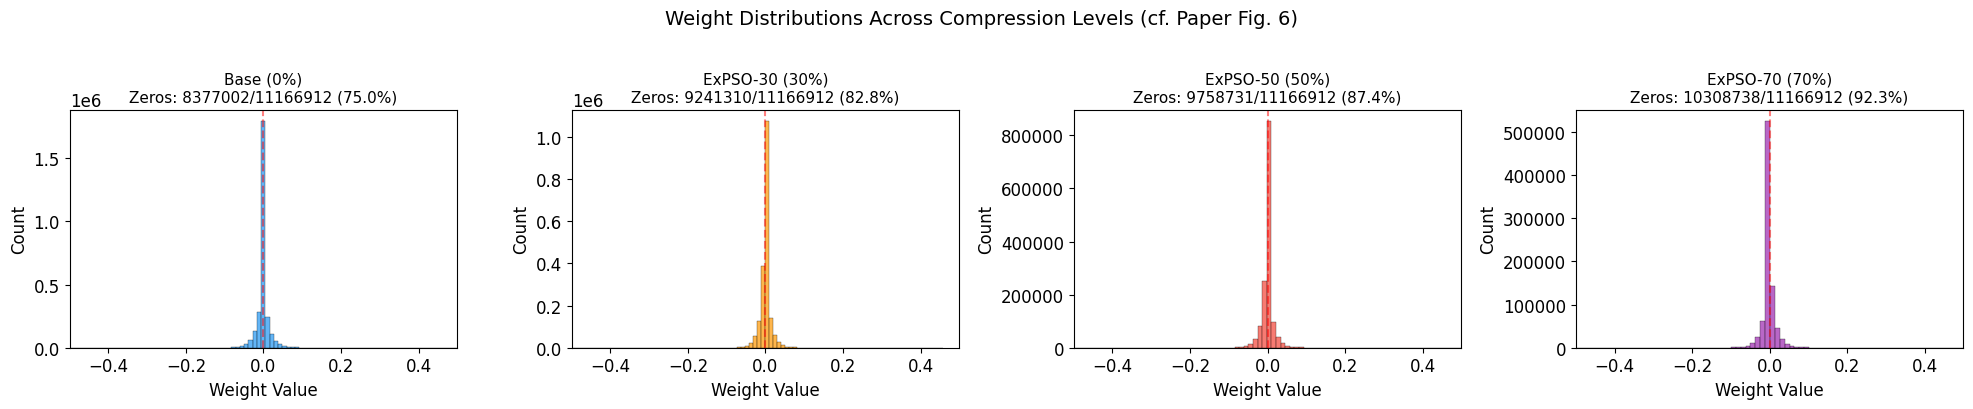

Saved: weight_distributions.png


In [8]:
# ==========================================================================
# WEIGHT DISTRIBUTION PLOTS (Paper Fig. 6 Equivalent)
# Shows how compression changes weight distributions at each sparsity level.
# ==========================================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

def get_all_weights(model):
    """Extract all conv layer weights as a flat numpy array."""
    weights = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            w = module.weight.data.cpu().numpy().flatten()
            weights.append(w)
    return np.concatenate(weights)

# Collect weights from each model
weight_models = {}
weight_models['Base (0%)'] = get_all_weights(models['Base'])
for r in [30, 50, 70]:
    key = f'ExPSO-{r}'
    if key in models:
        weight_models[f'ExPSO-{r} ({r}%)'] = get_all_weights(models[key])

# Plot histograms
fig, axes = plt.subplots(1, len(weight_models), figsize=(5*len(weight_models), 4))
if len(weight_models) == 1:
    axes = [axes]

colors = ['#2196F3', '#FF9800', '#F44336', '#9C27B0']
for idx, (label, weights) in enumerate(weight_models.items()):
    ax = axes[idx]
    total = len(weights)
    zeros = np.sum(np.abs(weights) < 1e-6)
    nonzero = weights[np.abs(weights) >= 1e-6]

    ax.hist(nonzero, bins=100, color=colors[idx % len(colors)], alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{label}\nZeros: {zeros}/{total} ({100*zeros/total:.1f}%)', fontsize=11)
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Count')
    ax.set_xlim(-0.5, 0.5)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Weight Distributions Across Compression Levels (cf. Paper Fig. 6)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('weight_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: weight_distributions.png')



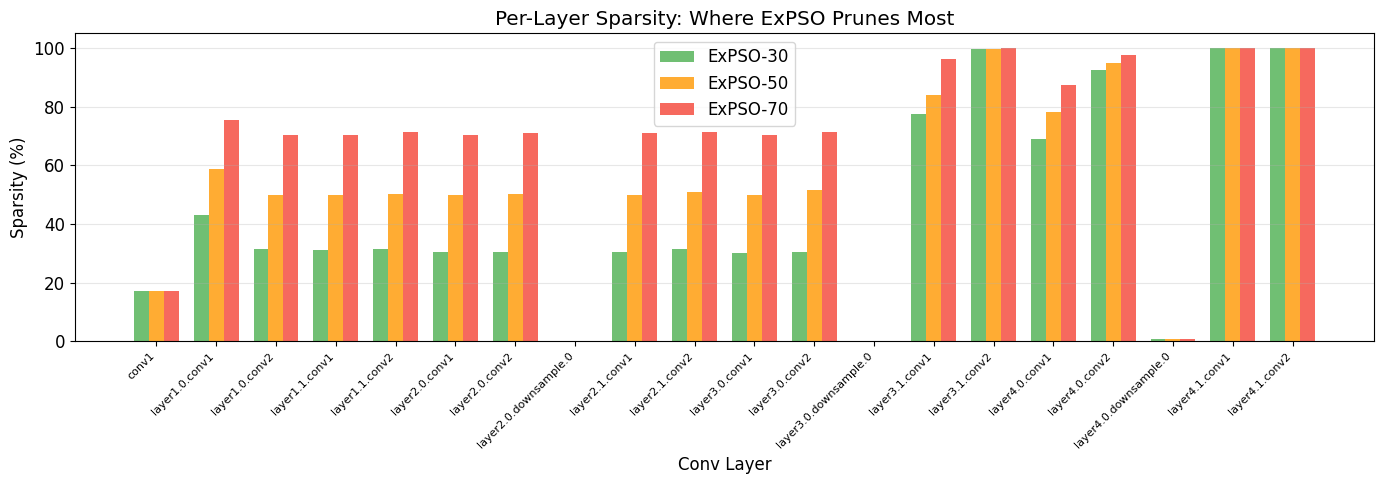

Saved: layer_sparsity.png


In [9]:
# ==========================================================================
# PER-LAYER SPARSITY HEATMAP
# Shows which layers ExPSO chose to prune most aggressively.
# ==========================================================================
def get_layer_sparsities(model):
    """Get sparsity % for each conv layer."""
    layer_names, sparsities = [], []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            w = module.weight.data.cpu()
            total = w.numel()
            zeros = (w.abs() < 1e-6).sum().item()
            layer_names.append(name.replace('module.', ''))
            sparsities.append(100.0 * zeros / total if total > 0 else 0)
    return layer_names, sparsities

fig, ax = plt.subplots(figsize=(14, 5))
x_offset = 0
bar_width = 0.25
colors_bar = {'ExPSO-30': '#4CAF50', 'ExPSO-50': '#FF9800', 'ExPSO-70': '#F44336'}

for i, r in enumerate([30, 50, 70]):
    key = f'ExPSO-{r}'
    if key in models:
        names, sparsities = get_layer_sparsities(models[key])
        x_pos = np.arange(len(names)) + i * bar_width
        ax.bar(x_pos, sparsities, bar_width, label=key, color=colors_bar.get(key, 'gray'), alpha=0.8)

ax.set_xlabel('Conv Layer')
ax.set_ylabel('Sparsity (%)')
ax.set_title('Per-Layer Sparsity: Where ExPSO Prunes Most')
ax.set_xticks(np.arange(len(names)) + bar_width)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('layer_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: layer_sparsity.png')



In [10]:
# ==========================================================================
# ABLATION: INDIVIDUAL EXPERT vs. SME vs. MVC-NNT
# ==========================================================================
print('\n' + '='*60)
print('ABLATION: Defense Strategy Comparison')
print('='*60)

# Compare: Single model vs Simple average vs SME (gated) vs MVC (random)
strategies = {}

# Single best expert
if 'ExPSO-30' in models:
    strategies['Single-Best(30%)'] = evaluate(models['ExPSO-30'], testloader,
        atk=torchattacks.PGD(models['ExPSO-30'], eps=eps, alpha=alpha, steps=20))

# Simple averaging ensemble
if all(f'ExPSO-{r}' in models for r in [30, 50, 70]):
    avg_correct = 0
    avg_total = 0
    expert_list = [models[f'ExPSO-{r}'] for r in [30, 50, 70]]
    # Create a wrapper for attack
    class AvgWrapper(nn.Module):
        def __init__(self, models_list):
            super().__init__()
            self.models_list = nn.ModuleList(models_list)
        def forward(self, x):
            out = sum(m(x) for m in self.models_list) / len(self.models_list)
            return out
    avg_model = AvgWrapper(expert_list).to(device)
    strategies['Avg-Ensemble'] = evaluate(avg_model, testloader,
        atk=torchattacks.PGD(avg_model, eps=eps, alpha=alpha, steps=20))

# SME
if 'SME' in models:
    strategies['SME(Gated)'] = evaluate(models['SME'], testloader,
        atk=torchattacks.PGD(models['SME'], eps=eps, alpha=alpha, steps=20))

# MVC-NNT
if 'MVC-NNT' in models:
    strategies['MVC-NNT(Random)'] = evaluate(models['MVC-NNT'], testloader,
        atk=torchattacks.PGD(models['MVC-NNT'], eps=eps, alpha=alpha, steps=20))


# Ultimate Hybrid (SME + MVC)
if 'Ultimate-Defense' in models:
    strategies['Ultimate(Hybrid)'] = evaluate(models['Ultimate-Defense'], testloader,
        atk=torchattacks.PGD(models['Ultimate-Defense'], eps=eps, alpha=alpha, steps=20))

print(f'\n{"Strategy":<22} {"Robust(PGD-20)":>14}')
print('-'*40)
for name, acc in strategies.items():
    print(f'{name:<22} {acc:>13.2f}%')


ABLATION: Defense Strategy Comparison

Strategy               Robust(PGD-20)
----------------------------------------
Single-Best(30%)               39.22%
Avg-Ensemble                   42.02%
SME(Gated)                     47.76%
MVC-NNT(Random)                43.79%
Ultimate(Hybrid)               47.21%
